<a href="https://colab.research.google.com/github/CoderCouple/hands-on-pytorch/blob/main/ch_01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PyTorch Workflow Fundamentals**

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
!nvidia-smi

Thu Sep 24 20:01:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# check the version of pytorch
torch.__version__

'2.11.0+cu128'

In [ ]:
# generating synthetic data

# parameters
weight = 0.7
bias = 0.3

# Generate data
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = X * weight + bias

X[:10], Y[:10]
X.shape, Y.shape


(torch.Size([50, 1]), torch.Size([50, 1]))

In [ ]:
# create training and test set

train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

In [ ]:
def  plot_predictions(train_data=X_train,
                    train_labels=Y_train,
                    test_data=X_test,
                    test_labels=Y_test,
                    predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});


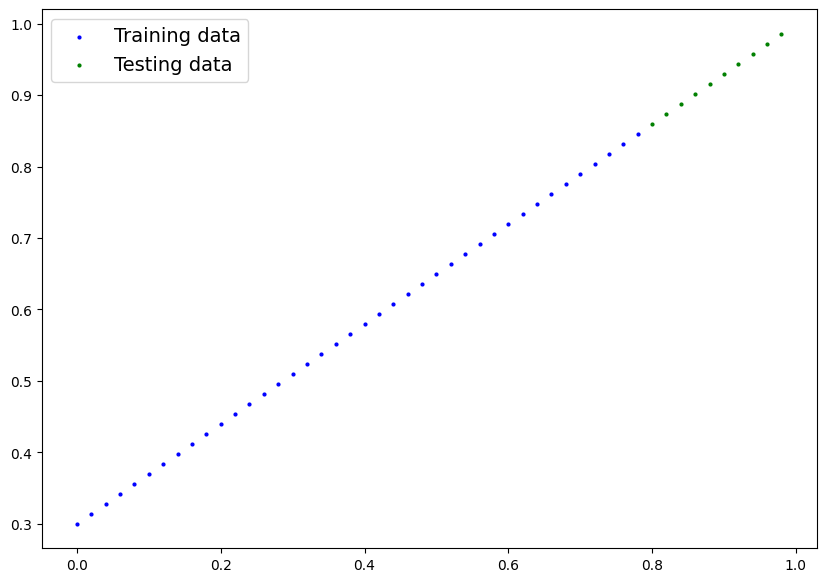

In [ ]:
plot_predictions();

In [ ]:
class LinearRegressionModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad = True)
    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad = True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model
model = LinearRegressionModelV1()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# lets make a prediction
with torch.inference_mode():
  y_preds = model(X_test)

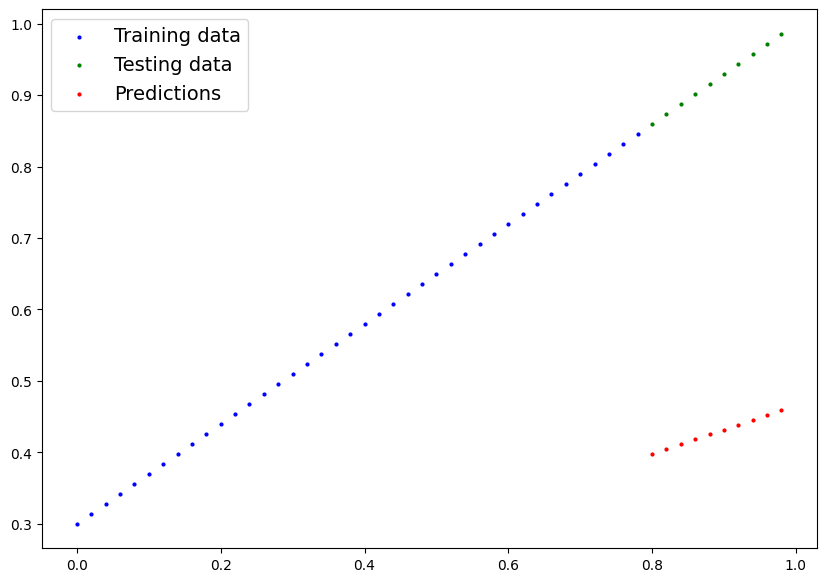

In [ ]:
plot_predictions(predictions=y_preds);

In [ ]:
# lets create the loss function
loss_fn = nn.L1Loss()

# create the optimizer
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)


In [ ]:
# create the traing loop

epochs = 200

train_losses = []
test_losses = []

for epoch in range(epochs):

  # put the model in traiing mode
  model.train()

  # Run the forward pass
  y_preds = model(X_train)

  # Calculate the loss function
  loss = loss_fn(y_preds,Y_train)

  # Remove any previous gradients
  optimizer.zero_grad()

  # Run the backward pass
  loss.backward()

  # Adjust the weights and biases
  optimizer.step()

  train_losses.append(loss.detach().numpy()) # Store training loss

  # put the model in evaluation loop
  model.eval()

  with torch.inference_mode():
    test_preds = model(X_test)
    test_loss = loss_fn(test_preds, Y_test)
    test_losses.append(test_loss.detach().numpy()) # Store testing loss

  if epoch % 10 == 0:
    print(f"Train Loss: {loss} Test loss: {test_loss}")

Train Loss: 0.31288138031959534 Test loss: 0.48106518387794495
Train Loss: 0.1976713240146637 Test loss: 0.3463551998138428
Train Loss: 0.08908725529909134 Test loss: 0.21729660034179688
Train Loss: 0.053148526698350906 Test loss: 0.14464017748832703
Train Loss: 0.04543796554207802 Test loss: 0.11360953003168106
Train Loss: 0.04167863354086876 Test loss: 0.09919948130846024
Train Loss: 0.03818932920694351 Test loss: 0.08886633068323135
Train Loss: 0.03476089984178543 Test loss: 0.0805937647819519
Train Loss: 0.03132382780313492 Test loss: 0.07232122868299484
Train Loss: 0.02788739837706089 Test loss: 0.06473556160926819
Train Loss: 0.024458957836031914 Test loss: 0.05646304413676262
Train Loss: 0.021020207554101944 Test loss: 0.04819049686193466
Train Loss: 0.01758546568453312 Test loss: 0.04060482233762741
Train Loss: 0.014155393466353416 Test loss: 0.03233227878808975
Train Loss: 0.010716589167714119 Test loss: 0.024059748277068138
Train Loss: 0.0072835334576666355 Test loss: 0.01647

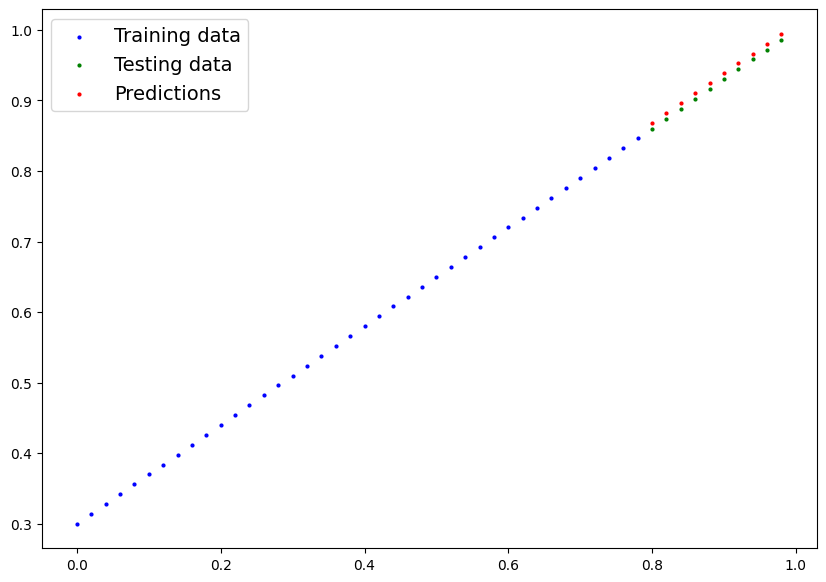

In [ ]:
plot_predictions(predictions=test_preds);

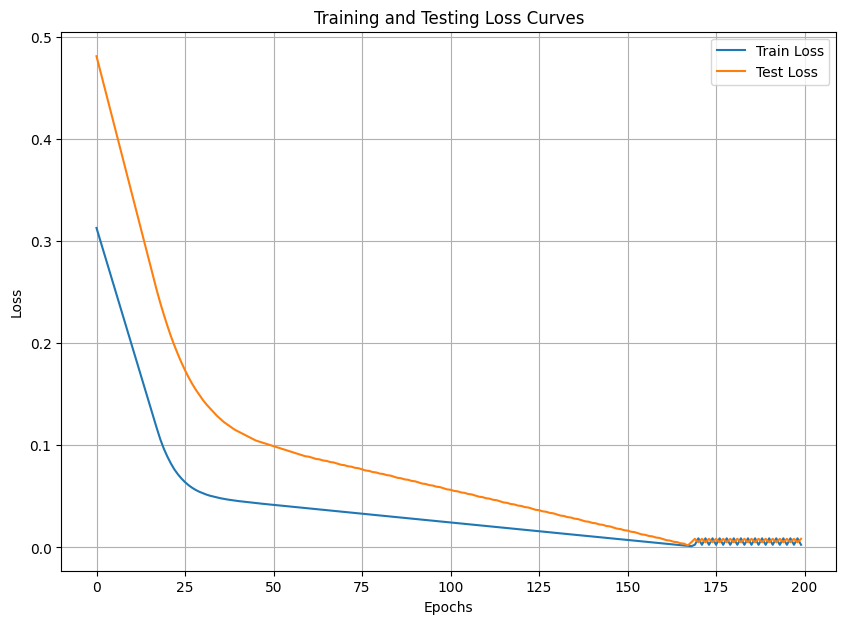

In [ ]:
# Plot the loss curves
plt.figure(figsize=(10, 7))
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), test_losses, label='Test Loss')
plt.title('Training and Testing Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
weight, bias

(0.7, 0.3)

# Final step Save and Load the model
* `torch.save()`
* `torch.load()`
* `torch.nn.Module.loade_stat_dict()`

In [ ]:
from pathlib import Path

MODEL_PATH= Path("data")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Model is saved at: {MODEL_SAVE_PATH}")


Model is saved at: data/01_pytorch_workflow_model.pth


In [ ]:
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

# Loding the saved module

In [ ]:
#Existing state
model.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# new created model with randome weights
model_loaded = LinearRegressionModelV1()
model_loaded.state_dict()

OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))])

In [ ]:
# lets load the state from the previous model in the newly created model
model_loaded.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
model_loaded.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])